In [5]:
! pip install torch torchvision numpy matplotlib opencv-python  

In [6]:
# This script performs sparse keypoint detection and matching using a pretrained VGG CNN.

import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

Your code goes here

In [7]:
# ImageNet normalization
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

def preprocess_for_cnn(bgr_img):
    rgb = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    tensor = torch.from_numpy(rgb).float().permute(2, 0, 1) / 255.0
    tensor = (tensor - mean[:, None, None]) / std[:, None, None]
    return tensor.unsqueeze(0)  # Add batch dimension
# Saliency-based Keypoint Detection
def get_keypoints_from_saliency(saliency, max_points=500):
    neighborhood = np.ones((3, 3), np.uint8)
    local_max = cv2.dilate(saliency.astype(np.float32), neighborhood)
    peaks = (saliency == local_max)
    coords = np.column_stack(np.nonzero(peaks))
    values = saliency[coords[:, 0], coords[:, 1]]
    sorted_idx = np.argsort(values)[::-1]
    coords = coords[sorted_idx]
    if max_points and coords.shape[0] > max_points:
        coords = coords[:max_points]
    return coords
# Load and Process Images
def download_image(url, filename):
    if not os.path.exists(filename):
        urllib.request.urlretrieve(url, filename)
def load_and_process_images(img1_path, img2_path):
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)

    if img1 is None or img2 is None:
        raise FileNotFoundError("Could not load one or both images. Check the paths or upload the images.")

    img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    tensor1 = preprocess_for_cnn(img1)
    tensor2 = preprocess_for_cnn(img2)

    with torch.no_grad():
        feat1 = cnn_feat_extractor(tensor1).squeeze(0)  # C x H x W
        feat2 = cnn_feat_extractor(tensor2).squeeze(0)

    sal1 = torch.norm(feat1, p=2, dim=0).cpu().numpy()
    sal2 = torch.norm(feat2, p=2, dim=0).cpu().numpy()

    coords1 = get_keypoints_from_saliency(sal1, max_points=500)
    coords2 = get_keypoints_from_saliency(sal2, max_points=500)

    H1, W1 = sal1.shape
    H2, W2 = sal2.shape
    keypoints1 = [(float(c * img1.shape[1] / W1), float(r * img1.shape[0] / H1)) for r, c in coords1]
    keypoints2 = [(float(c * img2.shape[1] / W2), float(r * img2.shape[0] / H2)) for r, c in coords2]

    descriptors1 = [feat1[:, r, c] / (feat1[:, r, c].norm() + 1e-8) for r, c in coords1]
    descriptors2 = [feat2[:, r, c] / (feat2[:, r, c].norm() + 1e-8) for r, c in coords2]

    desc1_np = torch.stack(descriptors1).cpu().numpy().astype(np.float32)
    desc2_np = torch.stack(descriptors2).cpu().numpy().astype(np.float32)

    return img1, img2, img1_gray, img2_gray, keypoints1, keypoints2, desc1_np, desc2_np
# Descriptor Matching
def match_descriptors(desc1, desc2, ratio_thresh=None):
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    knn_matches = bf.knnMatch(desc1, desc2, k=2)
    good_matches = [m for m, n in knn_matches if m.distance < ratio_thresh * n.distance]
    return good_matches
# Visualize Matches
def visualize_matches(img1, img2, kp1, kp2, matches, max_draw=30):
    kp_cv1 = [cv2.KeyPoint(float(x), float(y), 5) for (x, y) in kp1]
    kp_cv2 = [cv2.KeyPoint(float(x), float(y), 5) for (x, y) in kp2]
    img_matches = cv2.drawMatches(img1, kp_cv1, img2, kp_cv2, matches[:max_draw], None,
                                  flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.figure(figsize=(15, 8))
    plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f'Top {max_draw} Deep Feature Matches')
    plt.show()

In [8]:
model = torchvision.models.vgg16(pretrained=True).eval()
print(model.features)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 78.6MB/s] 


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

Your code goes here

Consider feature maps from the 5th layer of the VGG-16 model, matching ratio 0.5, for this, found 0 matches between feature maps from the two images for this layer, likely due to very low layer representations computed by this layer being incomparable for the two images

Layer: Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
Ratio: 0.5
Found 0 good matches


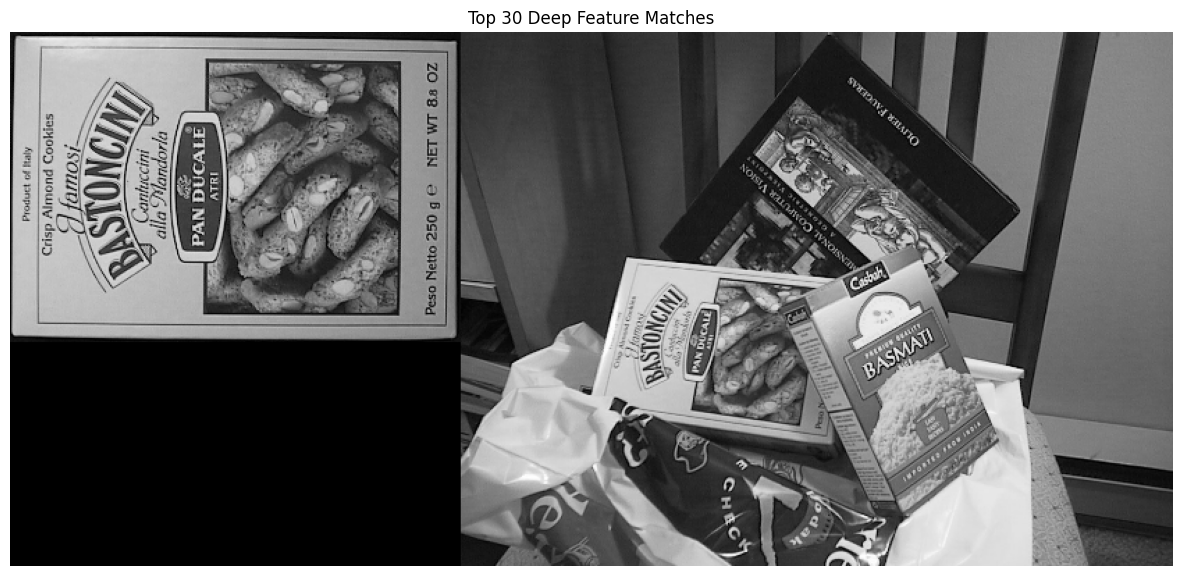

In [9]:
# Load Pretrained VGG Mode
model = torchvision.models.vgg16(pretrained=True).eval()
cnn_feat_extractor = model.features[:5] 

# Main Function
if __name__ == '__main__':
    download_image("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box.png", "image1.jpg")
    download_image("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box_in_scene.png", "image2.jpg")

    img1_path = 'image1.jpg'
    img2_path = 'image2.jpg'

    ratio_thresh = 0.5

    img1, img2, gray1, gray2, kp1, kp2, desc1, desc2 = load_and_process_images(img1_path, img2_path)
    
    matches = match_descriptors(desc1, desc2, ratio_thresh=ratio_thresh)
    
    print(f"Layer: {cnn_feat_extractor}")
    print(f"Ratio: {ratio_thresh}")
    print(f"Found {len(matches)} good matches")
    visualize_matches(img1, img2, kp1, kp2, matches)

Now, we try the 17th layer with the same matching ratio. Still no matches, hence next I try to increase the matching ratio for more leniency in matching

Layer: Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
Ratio: 0.5
Found 0 good m

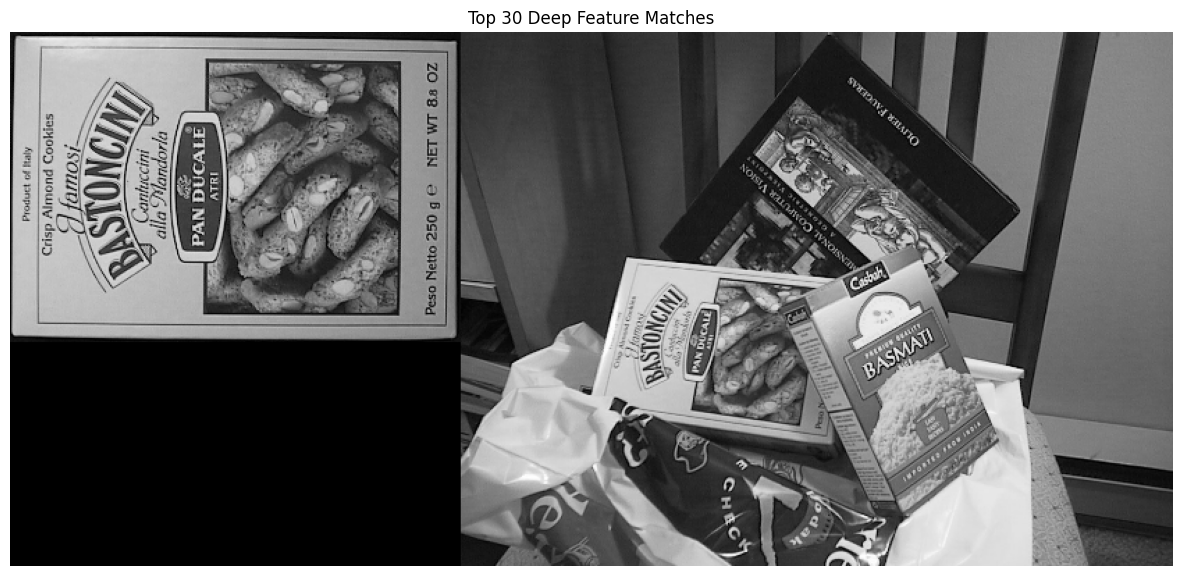

In [10]:
# Load Pretrained VGG Mode
model = torchvision.models.vgg16(pretrained=True).eval()
cnn_feat_extractor = model.features[:17] 

# Main Function
if __name__ == '__main__':
    download_image("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box.png", "image1.jpg")
    download_image("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box_in_scene.png", "image2.jpg")

    img1_path = 'image1.jpg'
    img2_path = 'image2.jpg'

    ratio_thresh = 0.5

    img1, img2, gray1, gray2, kp1, kp2, desc1, desc2 = load_and_process_images(img1_path, img2_path)
    
    matches = match_descriptors(desc1, desc2, ratio_thresh=ratio_thresh)
    
    print(f"Layer: {cnn_feat_extractor}")
    print(f"Ratio: {ratio_thresh}")
    print(f"Found {len(matches)} good matches")
    visualize_matches(img1, img2, kp1, kp2, matches)

17th layer, with a higher matching ratio 0.8. I found one match

Layer: Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
Ratio: 0.8
Found 1 good m

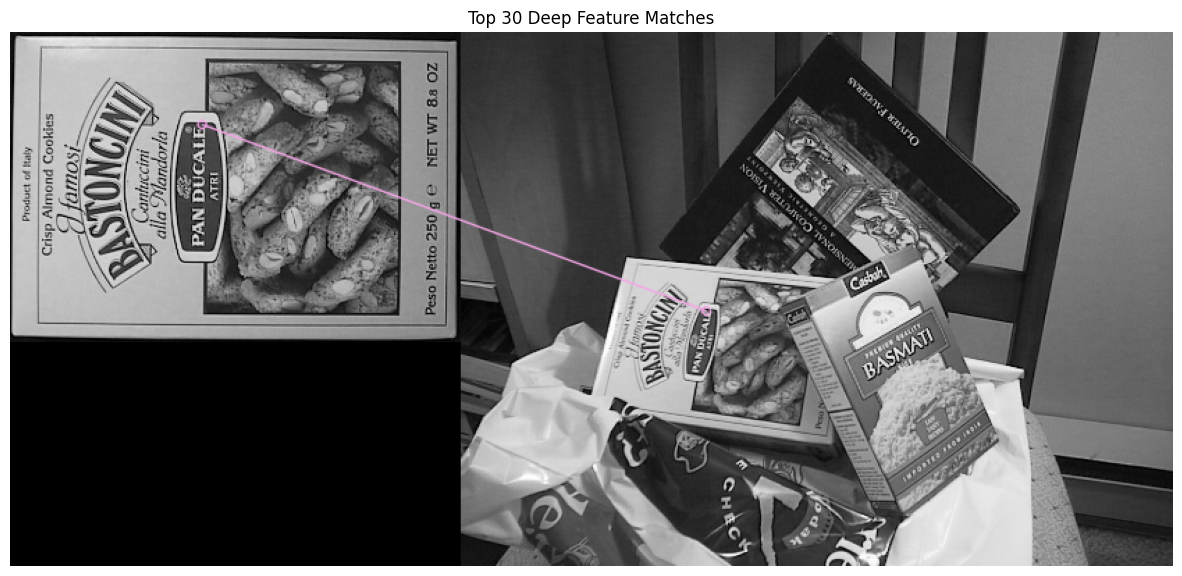

In [11]:
# Load Pretrained VGG Mode
model = torchvision.models.vgg16(pretrained=True).eval()
cnn_feat_extractor = model.features[:17] 

# Main Function
if __name__ == '__main__':
    download_image("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box.png", "image1.jpg")
    download_image("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box_in_scene.png", "image2.jpg")

    img1_path = 'image1.jpg'
    img2_path = 'image2.jpg'

    ratio_thresh = 0.8

    img1, img2, gray1, gray2, kp1, kp2, desc1, desc2 = load_and_process_images(img1_path, img2_path)
    
    matches = match_descriptors(desc1, desc2, ratio_thresh=ratio_thresh)
    
    print(f"Layer: {cnn_feat_extractor}")
    print(f"Ratio: {ratio_thresh}")
    print(f"Found {len(matches)} good matches")
    visualize_matches(img1, img2, kp1, kp2, matches)